# Notebook Purpose: Testing the use of TP-classification threshold=12ms and overlap removal threshold=12ms after filtering human annotations to remove annotations < 3dB SNR. Then we look at what kind of overlaps are considered as true positives or false positives and how many over ALL files

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [4]:
import convert_between_detector_file_formats as conversion

## Function and Constant Definitions

In [5]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}
FILE_SITES = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

RAVENPRO_TABLE_EXTENSION = ".txt"
RAVENPRO_TABLE_FORMAT = "\t"
RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
BD2_DETS_SAVE_DIR = Path(f'20250130__group_threshold_sweep_results')
TP_CLASSIFICATION_THRESHOLD = 0.012
OVERLAP_TIME_THRESHOLD = 0.012
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

### Below are the functions used for converting between detector formats

In [6]:
def return_true_positives_using_human_df(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=TP_CLASSIFICATION_THRESHOLD] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<TP_CLASSIFICATION_THRESHOLD] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    separated_performance_dfs = dict()
    separated_performance_dfs['machine_true_positives'] = machine_true_positives
    separated_performance_dfs['machine_false_positives'] = machine_false_positives
    separated_performance_dfs['machine_false_negatives'] = machine_false_negatives
    separated_performance_dfs['human_true_positives'] = human_bd2_true_positives

    return association_matrix, separated_performance_dfs

![image](example_confusion_matrix.png)

In [7]:
file_keys = list(FILE_SITES.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [50]:
SNR_thresh = 3
detthresh = 0.35
# for file_key in file_keys:
file_key = file_keys[0]
print(f'Computing measures for file {file_key}.WAV')
wav_filename = file_key
site = FILE_SITES[file_key]
plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=SNR_thresh].copy()

args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
median_peak_HF_freq = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='HF']['peak_frequency_WELCH'].median()
median_peak_LF_freq = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='LF']['peak_frequency_WELCH'].median()
print(f'Median LF frequency in File: {median_peak_LF_freq}')
print(f'Median HF frequency in File: {median_peak_HF_freq}')
lf_inds = (bd2_file_all_dets['peak_frequency_WELCH']<median_peak_LF_freq+7000)&(bd2_file_all_dets['peak_frequency_WELCH']>median_peak_LF_freq-7000)
hf_inds = (bd2_file_all_dets['peak_frequency_WELCH']>median_peak_HF_freq-7000)
lf_dets = bd2_file_all_dets[lf_inds&(bd2_file_all_dets['freq_group']=='LF')]
hf_dets = bd2_file_all_dets[hf_inds&(bd2_file_all_dets['freq_group']=='HF')]
fixed_dets = pd.concat([hf_dets, lf_dets]).sort_index()

Computing measures for file 20220730_053000.WAV
Median LF frequency in File: 25920.0
Median HF frequency in File: 72000.0


In [47]:
thresh_applied_bd2_dets = bd2_file_all_dets[bd2_file_all_dets['det_prob']>=detthresh].copy()
thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['SNR']>=SNR_thresh].copy()
thresh_applied_bd2_dets

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
10622,LF,231.284483,24000.0,25920.0,6.267903,231.2775,231.2891,25468,30247,Nyctalus leisleri,0.359,0.592,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10636,LF,231.661875,24000.0,24960.0,6.019741,231.6515,231.6635,24609,29885,Nyctalus leisleri,0.297,0.598,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10649,LF,231.942100,24000.0,24960.0,4.420469,231.9315,231.9459,24609,29998,Nyctalus leisleri,0.340,0.545,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10667,LF,232.223762,24000.0,25920.0,4.936040,232.2085,232.2283,24609,29249,Nyctalus leisleri,0.289,0.444,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10682,LF,232.419067,24000.0,24960.0,9.221212,232.4015,232.4206,24609,29436,Nyctalus leisleri,0.309,0.530,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76125,HF,1636.319250,48000.0,45120.0,8.484520,1636.3155,1636.3280,44375,49654,Pipistrellus pipistrellus,0.415,0.488,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
76139,HF,1636.565592,48000.0,45120.0,8.895263,1636.5625,1636.5707,44375,57442,Pipistrellus pipistrellus,0.538,0.639,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
76143,HF,1636.652150,48000.0,45120.0,5.408717,1636.6485,1636.6576,44375,54228,Pipistrellus pipistrellus,0.419,0.470,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
76183,HF,1637.527825,48000.0,47040.0,6.488708,1637.5225,1637.5343,45234,57239,Pipistrellus pipistrellus,0.379,0.454,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [48]:
thresh_applied_fixed_bd2_dets = fixed_dets[fixed_dets['det_prob']>=detthresh].copy()
thresh_applied_fixed_bd2_dets = thresh_applied_fixed_bd2_dets[thresh_applied_fixed_bd2_dets['SNR']>=SNR_thresh].copy()
thresh_applied_fixed_bd2_dets

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
10622,LF,231.284483,24000.0,25920.0,6.267903,231.2775,231.2891,25468,30247,Nyctalus leisleri,0.359,0.592,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10636,LF,231.661875,24000.0,24960.0,6.019741,231.6515,231.6635,24609,29885,Nyctalus leisleri,0.297,0.598,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10649,LF,231.942100,24000.0,24960.0,4.420469,231.9315,231.9459,24609,29998,Nyctalus leisleri,0.340,0.545,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10667,LF,232.223762,24000.0,25920.0,4.936040,232.2085,232.2283,24609,29249,Nyctalus leisleri,0.289,0.444,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
10682,LF,232.419067,24000.0,24960.0,9.221212,232.4015,232.4206,24609,29436,Nyctalus leisleri,0.309,0.530,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71524,LF,1537.061750,24000.0,22080.0,11.632322,1537.0555,1537.0655,21171,29259,Nyctalus noctula,0.365,0.571,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
71535,LF,1537.352513,24000.0,21120.0,10.160823,1537.3465,1537.3563,20312,28303,Nyctalus noctula,0.380,0.589,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
71552,LF,1537.694538,24000.0,20160.0,9.668054,1537.6905,1537.7014,19453,26289,Nyctalus noctula,0.438,0.610,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
71563,LF,1537.958896,24000.0,21120.0,7.750318,1537.9535,1537.9645,20312,26109,Nyctalus noctula,0.318,0.478,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [ ]:

association_matrix, separated_performance_dfs = return_true_positives_using_human_df(bd2_human_df_file, thresh_applied_bd2_dets)

human_true_positives = separated_performance_dfs['human_true_positives']
bd2_false_negatives = separated_performance_dfs['machine_false_negatives']
bd2_true_positives = separated_performance_dfs['machine_true_positives']
bd2_false_positives = separated_performance_dfs['machine_false_positives']

lf_bd2_human_df_file = human_true_positives[human_true_positives['freq_group']=='LF'].reset_index(drop=True).copy()
hf_bd2_human_df_file = human_true_positives[human_true_positives['freq_group']=='HF'].reset_index(drop=True).copy()

In [29]:
lf_bd2_true_positives = bd2_true_positives[bd2_true_positives['freq_group']=='LF'].reset_index(drop=True).copy()
lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_bd2_true_positives)

In [33]:
lf_bd2_true_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
0,LF,231.284483,24000.0,25920.0,6.267903,231.2775,231.2891,25468,30247,Nyctalus leisleri,0.359,0.592,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
1,LF,231.661875,24000.0,24960.0,6.019741,231.6515,231.6635,24609,29885,Nyctalus leisleri,0.297,0.598,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
2,LF,231.942100,24000.0,24960.0,4.420469,231.9315,231.9459,24609,29998,Nyctalus leisleri,0.340,0.545,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
3,LF,232.223762,24000.0,25920.0,4.936040,232.2085,232.2283,24609,29249,Nyctalus leisleri,0.289,0.444,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
4,LF,232.419067,24000.0,24960.0,9.221212,232.4015,232.4206,24609,29436,Nyctalus leisleri,0.309,0.530,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,LF,1536.638496,24000.0,22080.0,13.975776,1536.6325,1536.6429,22031,29387,Nyctalus noctula,0.352,0.564,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
86,LF,1537.061750,24000.0,22080.0,11.632322,1537.0555,1537.0655,21171,29259,Nyctalus noctula,0.365,0.571,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
87,LF,1537.352513,24000.0,21120.0,10.160823,1537.3465,1537.3563,20312,28303,Nyctalus noctula,0.380,0.589,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
88,LF,1537.694538,24000.0,20160.0,9.668054,1537.6905,1537.7014,19453,26289,Nyctalus noctula,0.438,0.610,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [30]:
lf_classified_human_true_positives = lf_separated_performance_dfs['human_true_positives']
lf_classified_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
lf_classified_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
lf_classified_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']

In [31]:
hf_bd2_true_positives = bd2_true_positives[bd2_true_positives['freq_group']=='HF'].reset_index(drop=True).copy()
hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_bd2_true_positives)

In [32]:
hf_classified_human_true_positives = hf_separated_performance_dfs['human_true_positives']
hf_classified_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
hf_classified_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
hf_classified_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']

Computing measures for file 20220730_053000.WAV
Computing measures for file 20220826_070000.WAV
Computing measures for file 20220727_083000.WAV
Computing measures for file 20220829_090000.WAV


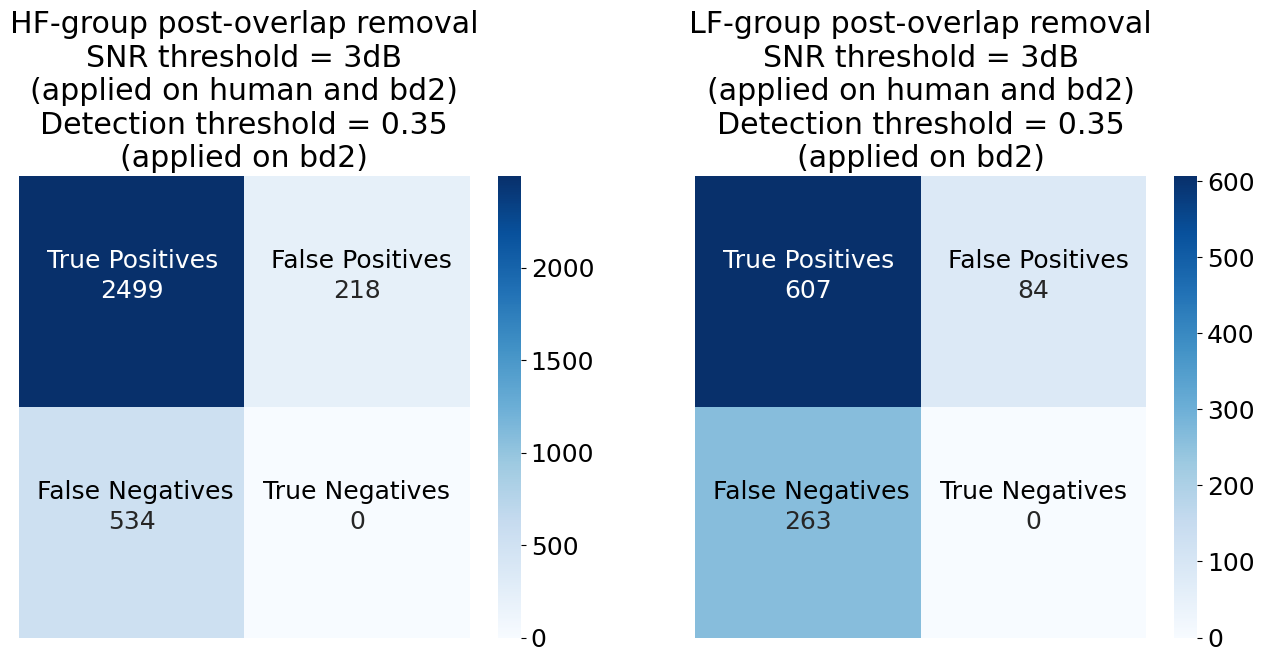

In [18]:
all_files_batdetct2_df = pd.DataFrame()
lf_files_batdetct2_df = pd.DataFrame()
hf_files_batdetct2_df = pd.DataFrame()

lf_files_human_df = pd.DataFrame()
hf_files_human_df = pd.DataFrame()

lf_files_true_positives_batdetct2_df = pd.DataFrame()
hf_files_true_positives_batdetct2_df = pd.DataFrame()
lf_files_true_positives_human_df = pd.DataFrame()
hf_files_true_positives_human_df = pd.DataFrame()

lf_files_false_positives_batdetct2_df = pd.DataFrame()
hf_files_false_positives_batdetct2_df = pd.DataFrame()

lf_files_false_negatives_batdetct2_df = pd.DataFrame()
hf_files_false_negatives_batdetct2_df = pd.DataFrame()

SNR_thresh = 3
detthresh = 0.35
for file_key in file_keys:
    print(f'Computing measures for file {file_key}.WAV')
    wav_filename = file_key
    site = FILE_SITES[file_key]
    plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
    raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

    snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
    bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
    bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
    bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                                'End Time (s)':'end_time',
                                'Low Freq (Hz)':'low_freq',
                                'High Freq (Hz)':'high_freq',
                                'Delta Time (s)':'delta_time_s',
                                'Manually-Verified Phonic Group':'freq_group',
                                'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
    bd2_human_df_file.sort_values('start_time', inplace=True)
    bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=SNR_thresh].copy()
    lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
    lf_files_human_df = pd.concat([lf_files_human_df, lf_bd2_human_df_file])
    hf_files_human_df = pd.concat([hf_files_human_df, hf_bd2_human_df_file])

    args = dict()
    args['chunk_size'] = 2
    args['detection_threshold'] = 0.00
    ones = int(args['detection_threshold'])
    decimals = int(int(100*(args['detection_threshold'])) % 100)
    threshold_tag = f"threshold{ones}p{decimals:02}"
    save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
    filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
    bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
    bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
    thresh_applied_bd2_dets = bd2_file_all_dets[bd2_file_all_dets['det_prob']>=detthresh].copy()
    thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['SNR']>=SNR_thresh].copy()

    lf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='LF'].reset_index(drop=True).copy()
    hf_thresh_applied_bd2_dets = thresh_applied_bd2_dets[thresh_applied_bd2_dets['freq_group']=='HF'].reset_index(drop=True).copy()

    all_files_batdetct2_df = pd.concat([all_files_batdetct2_df, thresh_applied_bd2_dets])
    lf_files_batdetct2_df = pd.concat([lf_files_batdetct2_df, lf_thresh_applied_bd2_dets])
    hf_files_batdetct2_df = pd.concat([hf_files_batdetct2_df, hf_thresh_applied_bd2_dets])

    lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_thresh_applied_bd2_dets)
    hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_thresh_applied_bd2_dets)

    lf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
    lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
    lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
    lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
    lf_files_true_positives_batdetct2_df = pd.concat([lf_files_true_positives_batdetct2_df, lf_bd2_true_positives])
    lf_files_false_positives_batdetct2_df = pd.concat([lf_files_false_positives_batdetct2_df, lf_bd2_false_positives])
    lf_files_false_negatives_batdetct2_df = pd.concat([lf_files_false_negatives_batdetct2_df, lf_bd2_false_negatives])
    lf_files_true_positives_human_df = pd.concat([lf_files_true_positives_human_df, lf_human_true_positives])

    hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
    hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
    hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
    hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
    hf_files_true_positives_batdetct2_df = pd.concat([hf_files_true_positives_batdetct2_df, hf_bd2_true_positives])
    hf_files_false_positives_batdetct2_df = pd.concat([hf_files_false_positives_batdetct2_df, hf_bd2_false_positives])
    hf_files_false_negatives_batdetct2_df = pd.concat([hf_files_false_negatives_batdetct2_df, hf_bd2_false_negatives])
    hf_files_true_positives_human_df = pd.concat([hf_files_true_positives_human_df, hf_human_true_positives])

lf_confusion_matrix = np.array([[len(lf_files_true_positives_batdetct2_df), len(lf_files_false_positives_batdetct2_df)],
                             [len(lf_files_false_negatives_batdetct2_df), 0]])
hf_confusion_matrix = np.array([[len(hf_files_true_positives_batdetct2_df), len(hf_files_false_positives_batdetct2_df)],
                             [len(hf_files_false_negatives_batdetct2_df), 0]])

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 6))
plt.rcParams.update({'font.size':18})

ax1.set_title(f'HF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on human and bd2)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(hf_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.text(x=0.125, y=0.4, s='True Positives', color='w')
ax1.text(x=1.12, y=0.4, s='False Positives', color='k')
ax1.text(x=0.08, y=1.4, s='False Negatives', color='k')
ax1.text(x=1.085, y=1.4, s='True Negatives', color='k')
ax1.set_xticks([])
ax1.set_yticks([])

ax2.set_title(f'LF-group post-overlap removal\nSNR threshold = {SNR_thresh}dB\n(applied on human and bd2)\nDetection threshold = {detthresh}\n(applied on bd2)')
sns.heatmap(lf_confusion_matrix, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.text(x=0.125, y=0.4, s='True Positives', color='w')
ax2.text(x=1.12, y=0.4, s='False Positives', color='k')
ax2.text(x=0.08, y=1.4, s='False Negatives', color='k')
ax2.text(x=1.085, y=1.4, s='True Negatives', color='k')
ax2.set_xticks([])
ax2.set_yticks([])

plt.show()

In [24]:
HF_precision = hf_confusion_matrix[0,0] / (hf_confusion_matrix[0,0] + hf_confusion_matrix[0,1])
HF_recall = hf_confusion_matrix[0,0] / (hf_confusion_matrix[0,0] + hf_confusion_matrix[1,0])
HF_f1score = (2*HF_precision*HF_recall) / (HF_precision+HF_recall)
np.array([HF_precision, HF_recall, HF_f1score]).round(3)

array([0.92 , 0.824, 0.869])

In [23]:
LF_precision = lf_confusion_matrix[0,0] / (lf_confusion_matrix[0,0] + lf_confusion_matrix[0,1])
LF_recall = lf_confusion_matrix[0,0] / (lf_confusion_matrix[0,0] + lf_confusion_matrix[1,0])
LF_f1score = (2*LF_precision*LF_recall) / (LF_precision+LF_recall)
np.array([LF_precision, LF_recall, LF_f1score]).round(3)

array([0.878, 0.698, 0.778])

In [22]:
all_confusion_matrix = lf_confusion_matrix + hf_confusion_matrix
all_precision = all_confusion_matrix[0,0] / (all_confusion_matrix[0,0] + all_confusion_matrix[0,1])
all_recall = all_confusion_matrix[0,0] / (all_confusion_matrix[0,0] + all_confusion_matrix[1,0])
all_f1score = (2*all_precision*all_recall) / (all_precision+all_recall)
np.array([all_precision, all_recall, all_f1score]).round(3)

array([0.911, 0.796, 0.85 ])